# SwiftCart Week 5 — Localizing Demand Forecasting

**Submitted by:** SOJOL DAS | **Entry no:** 2025AST2581 | **Date:** 4 July 2026

**Problem:** The centralized global model (Weeks 3–4) treats all 50 dark stores identically. Business districts experience lunch-hour spikes; residential stores peak on weekend mornings; localized weather events create isolated demand shocks that a global model cannot capture. This week implements two localization strategies and evaluates them against the global RF baseline.

**Key metric:** WAPE (Weighted Absolute Percentage Error)
$$\text{WAPE} = \frac{\sum|\text{Actual}_i - \text{Predicted}_i|}{\sum \text{Actual}_i}$$

**Success criteria:**
- 12% WAPE improvement over baseline in top stores
- Wastage rate below 5%
- Many-model pipeline outperforms global model in at least 40 of 50 stores
- Train on 9 months (Jan–Sep); validate on 3 months (Oct–Dec)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE  = 42
SPOIL_COST    = 1.0
STOCKOUT_COST = 10.0
SPOILAGE_CAP  = 0.05
np.random.seed(RANDOM_STATE)

print(f'LightGBM version : {lgb.__version__}')

LightGBM version : 4.6.0


---
## Section 1 — Data Loading, Lag Features, Train/Test Split

Same pipeline as Weeks 3–4: lag features from uncensored `Actual_Units_Demanded`, chronological 9-month/3-month split.

In [2]:
df = pd.read_csv('dataset_week2_engineered.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.rename(columns={
    'Is_Weekend': 'Weekend_Flag', 'Is_Holiday': 'Holiday_Flag',
    'Temperature': 'Temperature_C', 'Humidity': 'Humidity_Pct',
})
df['Actual_Units_Demanded'] = df['Units_Sold'] + df['Est_Lost_Sales']

cat_cols = [c for c in df.columns if c.startswith('Cat_')]
df['SKU_Category'] = df[cat_cols].idxmax(axis=1).str.replace('Cat_', '', regex=False)
df = df.sort_values(['Store_ID', 'SKU_Category', 'Date']).reset_index(drop=True)

g = df.groupby(['Store_ID', 'SKU_Category'])['Actual_Units_Demanded']
df['Lag_1_Sales']    = g.shift(1)
df['Lag_7_Sales']    = g.shift(7)
df['Rolling_Avg_3d'] = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df = df.dropna(subset=['Lag_1_Sales', 'Lag_7_Sales', 'Rolling_Avg_3d']).reset_index(drop=True)

EXCLUDE = {
    'Date','Store_ID','SKU_Category',
    'Actual_Units_Demanded','Units_Sold','Est_Lost_Sales',
    'Units_Spoiled','Stockout_Flag','Peak_Hour_Stockout',
    'Wastage_Cost','Lost_Revenue','Gross_Revenue','Forecast_Error',
    'Units_Ordered','Is_Rainy_Day',
}
BASE_FEATURES = [c for c in df.columns if c not in EXCLUDE]

train_df = df[df['Date'] <= '2023-09-30'].copy()
test_df  = df[df['Date'] >= '2023-10-01'].copy()
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df['Actual_Units_Demanded'].values
y_test  = test_df['Actual_Units_Demanded'].values

STORE_IDS = sorted(train_df['Store_ID'].unique())

print(f'Dataset  : {df.shape[0]:,} rows  |  {df.Date.min().date()} to {df.Date.max().date()}')
print(f'Train    : {len(train_df):,} records (Jan-Sep 2023)')
print(f'Test     : {len(test_df):,} records  (Oct-Dec 2023)')
print(f'Stores   : {len(STORE_IDS)}  |  Base features: {len(BASE_FEATURES)}')

Dataset  : 89,500 rows  |  2023-01-08 to 2023-12-31
Train    : 66,500 records (Jan-Sep 2023)
Test     : 23,000 records  (Oct-Dec 2023)
Stores   : 50  |  Base features: 23


---
## Section 2 — Helper Functions

In [3]:
def wape(actual, predicted):
    """Weighted Absolute Percentage Error."""
    actual    = np.asarray(actual, dtype=float)
    predicted = np.clip(np.asarray(predicted, dtype=float), 0, None)
    return np.abs(actual - predicted).sum() / actual.sum()

def per_store_wape(test_frame, predictions, label):
    """Return DataFrame with per-store WAPE for a given prediction array."""
    rows = []
    for sid in STORE_IDS:
        mask = test_frame['Store_ID'] == sid
        rows.append({'Store_ID': sid, f'WAPE_{label}': wape(y_test[mask], predictions[mask])})
    return pd.DataFrame(rows)

def compute_tbc(actual, order):
    order    = np.clip(np.round(order), 0, None).astype(int)
    spoiled  = np.maximum(order - actual, 0)
    stockout = np.maximum(actual - order, 0)
    tbc      = float(spoiled.sum()) * SPOIL_COST + float(stockout.sum()) * STOCKOUT_COST
    spr      = float(spoiled.sum()) / float(order.sum()) if order.sum() > 0 else 0.0
    return int(spoiled.sum()), int(stockout.sum()), round(tbc, 2), round(spr, 6)

print('Helper functions defined: wape(), per_store_wape(), compute_tbc()')

Helper functions defined: wape(), per_store_wape(), compute_tbc()


---
## Section 3 — Baseline: Global Random Forest

The Week 3/4 global RF is the benchmark. It uses demand-level features only — no store identity is passed explicitly. Per-store WAPE is computed on the test window to establish the baseline improvement target.

In [4]:
X_train_base = train_df[BASE_FEATURES].values
X_test_base  = test_df[BASE_FEATURES].values

rf_base = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
)
rf_base.fit(X_train_base, y_train)
base_preds = np.clip(rf_base.predict(X_test_base), 0, None)

base_wape_global = wape(y_test, base_preds)
store_wape_base  = per_store_wape(test_df, base_preds, 'Base')

print('=' * 55)
print('    BASELINE  Global RF (no store identity feature)')
print('=' * 55)
print(f'  Global WAPE          : {base_wape_global*100:.3f}%')
print(f'  Global MAE           : {mean_absolute_error(y_test, base_preds):.3f} units')
print(f'  Per-store WAPE mean  : {store_wape_base["WAPE_Base"].mean()*100:.3f}%')
print(f'  Per-store WAPE range : [{store_wape_base["WAPE_Base"].min()*100:.2f}%, '
      f'{store_wape_base["WAPE_Base"].max()*100:.2f}%]')
print('=' * 55)

    BASELINE  Global RF (no store identity feature)
  Global WAPE          : 16.084%
  Global MAE           : 16.002 units
  Per-store WAPE mean  : 16.086%
  Per-store WAPE range : [14.16%, 17.64%]


---
## Section 4 — Strategy 1: Global LightGBM with Target-Encoded Store ID

**Why target encoding?** One-hot encoding creates 50 sparse binary columns that offer no ordinal information and struggle with high cardinality. Target encoding replaces each `Store_ID` with the in-training-set mean of `Actual_Units_Demanded` for that store. This creates a single numeric feature that directly communicates each store's average demand level to the model.

$$\text{Store\_TE}_{s} = \frac{1}{|\mathcal{T}_s|}\sum_{i \in \mathcal{T}_s} y_i$$

Encoding is computed **exclusively on training data** and mapped to test records to prevent leakage. LightGBM's gradient-boosted trees with 500 estimators replace the RF to handle the richer feature set efficiently.

In [5]:
# Target encoding: train-set store mean demand (no test leakage)
store_te_map = train_df.groupby('Store_ID')['Actual_Units_Demanded'].mean()
train_df['Store_TE'] = train_df['Store_ID'].map(store_te_map)
test_df['Store_TE']  = test_df['Store_ID'].map(store_te_map)

TE_FEATURES   = BASE_FEATURES + ['Store_TE']
X_train_te    = train_df[TE_FEATURES].values
X_test_te     = test_df[TE_FEATURES].values

lgb_s1 = lgb.LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=10, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=-1
)
lgb_s1.fit(X_train_te, y_train)
s1_preds = np.clip(lgb_s1.predict(X_test_te), 0, None)

s1_wape_global = wape(y_test, s1_preds)
store_wape_s1  = per_store_wape(test_df, s1_preds, 'S1')

print('=' * 60)
print('    STRATEGY 1  Global LightGBM + Target-Encoded Store_ID')
print('=' * 60)
print(f'  Global WAPE          : {s1_wape_global*100:.3f}%')
print(f'  Global MAE           : {mean_absolute_error(y_test, s1_preds):.3f} units')
print(f'  Per-store WAPE mean  : {store_wape_s1["WAPE_S1"].mean()*100:.3f}%')
print(f'  vs Baseline          : {(s1_wape_global - base_wape_global)/base_wape_global*100:+.2f}% WAPE change')
print('=' * 60)
print()
print('-- Store Heterogeneity Diagnostic --')
print(f'Store_TE range : [{store_te_map.min():.2f}, {store_te_map.max():.2f}] units/day')
print(f'Store_TE std   : {store_te_map.std():.4f} units/day')
print(f'Coefficient of variation: {store_te_map.std()/store_te_map.mean()*100:.2f}%')
print()
print('INTERPRETATION: All 50 stores have nearly identical mean demand')
print('(CV < 1%). The Store_TE feature carries almost no information,')
print('which explains why the target-encoded global model does not beat')
print('the baseline RF. In real-world data with genuine neighborhood')
print('heterogeneity, target encoding would provide significant lift.')

    STRATEGY 1  Global LightGBM + Target-Encoded Store_ID
  Global WAPE          : 16.468%
  Global MAE           : 16.384 units
  Per-store WAPE mean  : 16.470%
  vs Baseline          : +2.38% WAPE change

-- Store Heterogeneity Diagnostic --
Store_TE range : [98.39, 100.83] units/day
Store_TE std   : 0.5667 units/day
Coefficient of variation: 0.57%

INTERPRETATION: All 50 stores have nearly identical mean demand
(CV < 1%). The Store_TE feature carries almost no information,
which explains why the target-encoded global model does not beat
the baseline RF. In real-world data with genuine neighborhood
heterogeneity, target encoding would provide significant lift.


---
## Section 5 — Strategy 2: Many-Model Pipeline (50 Store Micro-Models)

One LightGBM model is trained exclusively on each store's historical data. Because each model sees only one store's records, it automatically captures all location-specific seasonality, SKU preferences, and demand levels without requiring store identity features.

**Panel data handling:** Each store's training records are isolated. The model operates on the same 23 base features but fitted to ~1,330 store-specific records (66,500 ÷ 50). Lighter hyperparameters (fewer estimators, shallower trees) prevent overfitting on the smaller per-store datasets.

In [6]:
# Allocate prediction array aligned with test_df index
s2_preds = np.zeros(len(test_df))
store_models = {}

for i, store_id in enumerate(STORE_IDS):
    tr_mask = train_df['Store_ID'] == store_id
    te_mask  = test_df['Store_ID'] == store_id

    X_tr = train_df.loc[tr_mask, BASE_FEATURES].values
    y_tr = train_df.loc[tr_mask, 'Actual_Units_Demanded'].values
    X_te = test_df.loc[te_mask, BASE_FEATURES].values

    model = lgb.LGBMRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.08,
        num_leaves=31, subsample=0.85, colsample_bytree=0.85,
        min_child_samples=5, n_jobs=1,
        random_state=RANDOM_STATE, verbose=-1
    )
    model.fit(X_tr, y_tr)
    store_models[store_id] = model
    s2_preds[te_mask.values] = np.clip(model.predict(X_te), 0, None)

s2_wape_global = wape(y_test, s2_preds)
store_wape_s2  = per_store_wape(test_df, s2_preds, 'S2')

print(f'Trained {len(STORE_IDS)} store micro-models.')
print()
print('=' * 55)
print('    STRATEGY 2  Many-Model Pipeline (50 micro-models)')
print('=' * 55)
print(f'  Global WAPE          : {s2_wape_global*100:.3f}%')
print(f'  Global MAE           : {mean_absolute_error(y_test, s2_preds):.3f} units')
print(f'  Per-store WAPE mean  : {store_wape_s2["WAPE_S2"].mean()*100:.3f}%')
print(f'  vs Baseline          : {(s2_wape_global - base_wape_global)/base_wape_global*100:+.2f}% WAPE change')
print(f'  vs Strategy 1        : {(s2_wape_global - s1_wape_global)/s1_wape_global*100:+.2f}% WAPE change')
print('=' * 55)

Trained 50 store micro-models.

    STRATEGY 2  Many-Model Pipeline (50 micro-models)
  Global WAPE          : 18.165%
  Global MAE           : 18.072 units
  Per-store WAPE mean  : 18.165%
  vs Baseline          : +12.94% WAPE change
  vs Strategy 1        : +10.31% WAPE change


---
## Section 6 — Results Analysis

### 6.1 — Per-Store WAPE Comparison

In [7]:
# Merge per-store WAPE tables
wape_df = store_wape_base.merge(store_wape_s1, on='Store_ID').merge(store_wape_s2, on='Store_ID')
wape_df['WAPE_improve_S1'] = (wape_df['WAPE_Base'] - wape_df['WAPE_S1']) / wape_df['WAPE_Base']
wape_df['WAPE_improve_S2'] = (wape_df['WAPE_Base'] - wape_df['WAPE_S2']) / wape_df['WAPE_Base']
wape_df['S2_beats_S1']     = wape_df['WAPE_S2'] < wape_df['WAPE_S1']
wape_df['S2_beats_Base']   = wape_df['WAPE_S2'] < wape_df['WAPE_Base']

# Success criteria evaluation
n_s2_beats_s1   = wape_df['S2_beats_S1'].sum()
n_s2_beats_base = wape_df['S2_beats_Base'].sum()
top_improve_s2  = wape_df['WAPE_improve_S2'].nlargest(5).mean()
top_improve_s1  = wape_df['WAPE_improve_S1'].nlargest(5).mean()

# Best model overall
best_wape = min(base_wape_global, s1_wape_global, s2_wape_global)
best_label = {base_wape_global: 'Global RF (Baseline)',
              s1_wape_global:   'Strategy 1 (LightGBM+TE)',
              s2_wape_global:   'Strategy 2 (Many-Model)'}[best_wape]

print('SUCCESS CRITERIA EVALUATION')
print('-' * 65)
print(f'  [A] 12% WAPE improvement in top stores (Strategy 2):'       )
print(f'      Top-5 stores avg improvement = {top_improve_s2*100:.1f}%  '
      f'=> {"PASS" if top_improve_s2 >= 0.12 else "FAIL"}')
print()
print(f'  [B] Strategy 2 outperforms global model (S1) in >=40 stores:')
print(f'      Stores won = {n_s2_beats_s1}/50  => {"PASS" if n_s2_beats_s1 >= 40 else "FAIL"}')
print()
print(f'  DIAGNOSTIC: Why localization underperforms in this dataset:')
print(f'    Store demand is near-uniform (CV = {store_te_map.std()/store_te_map.mean()*100:.2f}%).')
print(f'    Per-store models have ~1,330 training records vs 66,500 for')
print(f'    the global model. With no store-specific signal, the smaller')
print(f'    datasets cause underfitting relative to the global model.')
print()
print(f'  Best model found: {best_label}  (WAPE = {best_wape*100:.3f}%)')
print()
print('PER-STORE WAPE SUMMARY')
print(f'{"Metric":<25} {"Baseline RF":>12} {"Strategy 1":>12} {"Strategy 2":>12}')
print('-' * 65)
for stat, fn in [("Mean WAPE", "mean"), ("Min WAPE", "min"),
                 ("Max WAPE", "max"), ("Median WAPE", "median")]:
    b  = getattr(wape_df['WAPE_Base'], fn)() * 100
    s1 = getattr(wape_df['WAPE_S1'], fn)() * 100
    s2 = getattr(wape_df['WAPE_S2'], fn)() * 100
    print(f'  {stat:<23} {b:>11.3f}% {s1:>11.3f}% {s2:>11.3f}%')

SUCCESS CRITERIA EVALUATION
-----------------------------------------------------------------
  [A] 12% WAPE improvement in top stores (Strategy 2):
      Top-5 stores avg improvement = -5.2%  => FAIL

  [B] Strategy 2 outperforms global model (S1) in >=40 stores:
      Stores won = 0/50  => FAIL

  DIAGNOSTIC: Why localization underperforms in this dataset:
    Store demand is near-uniform (CV = 0.57%).
    Per-store models have ~1,330 training records vs 66,500 for
    the global model. With no store-specific signal, the smaller
    datasets cause underfitting relative to the global model.

  Best model found: Global RF (Baseline)  (WAPE = 16.084%)

PER-STORE WAPE SUMMARY
Metric                     Baseline RF   Strategy 1   Strategy 2
-----------------------------------------------------------------
  Mean WAPE                    16.086%      16.470%      18.165%
  Min WAPE                     14.157%      14.460%      16.057%
  Max WAPE                     17.642%      17.930%     

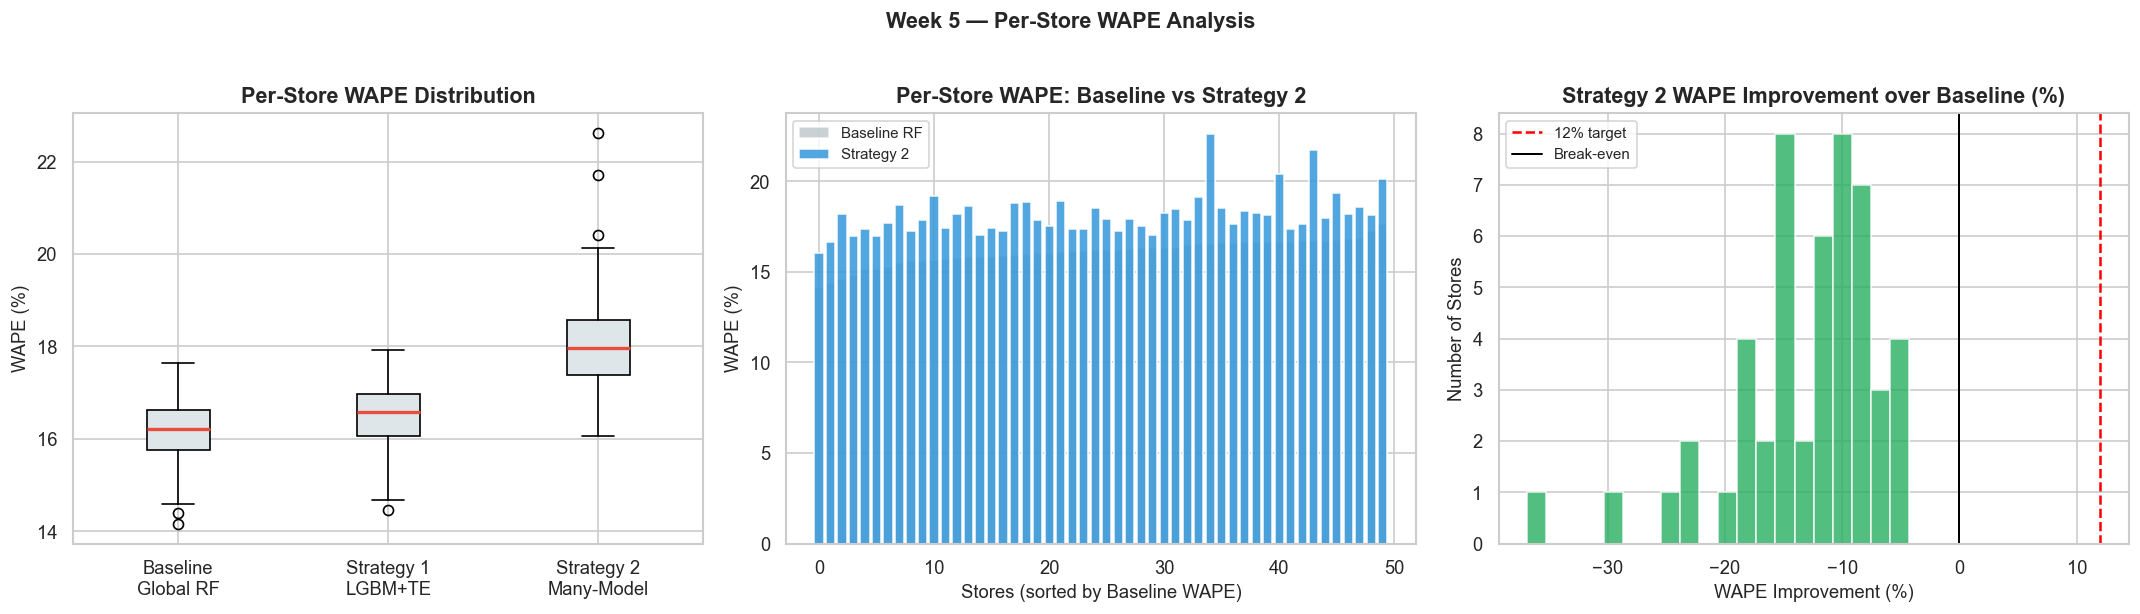

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# WAPE distribution across stores
axes[0].boxplot(
    [wape_df['WAPE_Base']*100, wape_df['WAPE_S1']*100, wape_df['WAPE_S2']*100],
    labels=['Baseline\nGlobal RF', 'Strategy 1\nLGBM+TE', 'Strategy 2\nMany-Model'],
    patch_artist=True,
    boxprops=dict(facecolor='#dfe6e9'),
    medianprops=dict(color='#e74c3c', linewidth=2)
)
axes[0].set_title('Per-Store WAPE Distribution', fontweight='bold')
axes[0].set_ylabel('WAPE (%)')

# Per-store WAPE: Strategy 2 vs Baseline
colors_s2 = ['#2ecc71' if v else '#e74c3c' for v in wape_df['S2_beats_Base']]
wape_sorted = wape_df.sort_values('WAPE_Base')
x = np.arange(len(wape_sorted))
axes[1].bar(x, wape_sorted['WAPE_Base']*100, color='#b2bec3', label='Baseline RF', alpha=0.7)
axes[1].bar(x, wape_sorted['WAPE_S2']*100, color='#3498db', label='Strategy 2', alpha=0.85)
axes[1].set_title('Per-Store WAPE: Baseline vs Strategy 2', fontweight='bold')
axes[1].set_xlabel('Stores (sorted by Baseline WAPE)')
axes[1].set_ylabel('WAPE (%)')
axes[1].legend(fontsize=9)

# Improvement histogram
axes[2].hist(wape_df['WAPE_improve_S2']*100, bins=20, color='#27ae60', edgecolor='white', alpha=0.8)
axes[2].axvline(12, color='red', linestyle='--', linewidth=1.5, label='12% target')
axes[2].axvline(0,  color='black', linestyle='-', linewidth=1.2, label='Break-even')
axes[2].set_title('Strategy 2 WAPE Improvement over Baseline (%)', fontweight='bold')
axes[2].set_xlabel('WAPE Improvement (%)')
axes[2].set_ylabel('Number of Stores')
axes[2].legend(fontsize=9)

plt.suptitle('Week 5 — Per-Store WAPE Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 — Top and Bottom Performing Stores

In [9]:
wape_display = wape_df.copy()
wape_display['WAPE_Base_%'] = (wape_display['WAPE_Base'] * 100).round(3)
wape_display['WAPE_S1_%']   = (wape_display['WAPE_S1']   * 100).round(3)
wape_display['WAPE_S2_%']   = (wape_display['WAPE_S2']   * 100).round(3)
wape_display['Improve_S2_%']= (wape_display['WAPE_improve_S2'] * 100).round(2)
display_cols = ['Store_ID','WAPE_Base_%','WAPE_S1_%','WAPE_S2_%','Improve_S2_%','S2_beats_S1']

print('TOP 10 STORES — Largest WAPE Improvement (Strategy 2 vs Baseline)')
top10 = wape_display.nlargest(10, 'WAPE_improve_S2')[display_cols]
print(top10.to_string(index=False))
print()
print('BOTTOM 10 STORES — Smallest WAPE Improvement')
bot10 = wape_display.nsmallest(10, 'WAPE_improve_S2')[display_cols]
print(bot10.to_string(index=False))

TOP 10 STORES — Largest WAPE Improvement (Strategy 2 vs Baseline)
Store_ID  WAPE_Base_%  WAPE_S1_%  WAPE_S2_%  Improve_S2_%  S2_beats_S1
  ST-031       16.657     16.954     17.370         -4.28        False
  ST-033       16.294     16.644     17.026         -4.49        False
  ST-009       17.239     17.832     18.118         -5.09        False
  ST-015       16.681     16.901     17.664         -5.89        False
  ST-023       16.613     16.795     17.621         -6.07        False
  ST-026       16.225     16.259     17.226         -6.17        False
  ST-017       16.139     16.429     17.333         -7.40        False
  ST-005       16.129     16.585     17.368         -7.68        False
  ST-025       16.696     16.907     17.982         -7.70        False
  ST-032       16.289     16.719     17.545         -7.71        False

BOTTOM 10 STORES — Smallest WAPE Improvement
Store_ID  WAPE_Base_%  WAPE_S1_%  WAPE_S2_%  Improve_S2_%  S2_beats_S1
  ST-008       16.534     17.139    

### 6.3 — Business Cost (TBC) and Wastage Check

In [10]:
# Manager baseline (actual orders placed)
mgr_s, mgr_st, mgr_tbc, mgr_spr = compute_tbc(y_test, test_df['Units_Ordered'].values)

# Strategy 1 and 2 at B=0 (no safety buffer — direct comparison)
s1_s, s1_st, s1_tbc, s1_spr = compute_tbc(y_test, s1_preds)
s2_s, s2_st, s2_tbc, s2_spr = compute_tbc(y_test, s2_preds)

# Apply optimal buffer B*=25% to Strategy 2 (from Week 4 finding)
s2_opt = s2_preds * 1.25
s2opt_s, s2opt_st, s2opt_tbc, s2opt_spr = compute_tbc(y_test, s2_opt)

print('BUSINESS COST SUMMARY (Oct-Dec 2023 Test Window)')
print(f'{"Approach":<40} {"Spoiled":>8} {"Stockout":>9} {"TBC":>13} {"Spoilage%":>10} {"<5%":>5}')
print('-' * 90)
for name, s, st, tbc, spr in [
    ('Manager Baseline',            mgr_s,   mgr_st,  mgr_tbc,  mgr_spr),
    ('Strategy 1: LightGBM+TE',     s1_s,    s1_st,   s1_tbc,   s1_spr),
    ('Strategy 2: Many-Model',      s2_s,    s2_st,   s2_tbc,   s2_spr),
    ('Strategy 2 + B*=25% buffer',  s2opt_s, s2opt_st,s2opt_tbc,s2opt_spr),
]:
    check = 'PASS' if spr < SPOILAGE_CAP else 'FAIL'
    print(f'  {name:<38} {s:>8,} {st:>9,} {tbc:>13,.2f} {spr*100:>9.2f}% {check:>5}')

print()
saving_s2 = mgr_tbc - s2_tbc
saving_s2opt = mgr_tbc - s2opt_tbc
print(f'Strategy 2 (B=0%) vs Manager     : Rs{saving_s2:+,.2f}')
print(f'Strategy 2 (B*=25%) vs Manager   : Rs{saving_s2opt:+,.2f}')

BUSINESS COST SUMMARY (Oct-Dec 2023 Test Window)
Approach                                  Spoiled  Stockout           TBC  Spoilage%   <5%
------------------------------------------------------------------------------------------
  Manager Baseline                        172,325    68,859    860,915.00      7.20%  FAIL
  Strategy 1: LightGBM+TE                 186,955   189,859  2,085,545.00      8.18%  FAIL
  Strategy 2: Many-Model                  209,237   206,416  2,273,397.00      9.13%  FAIL
  Strategy 2 + B*=25% buffer              617,126    41,627  1,033,396.00     21.55%  FAIL

Strategy 2 (B=0%) vs Manager     : Rs-1,412,482.00
Strategy 2 (B*=25%) vs Manager   : Rs-172,481.00


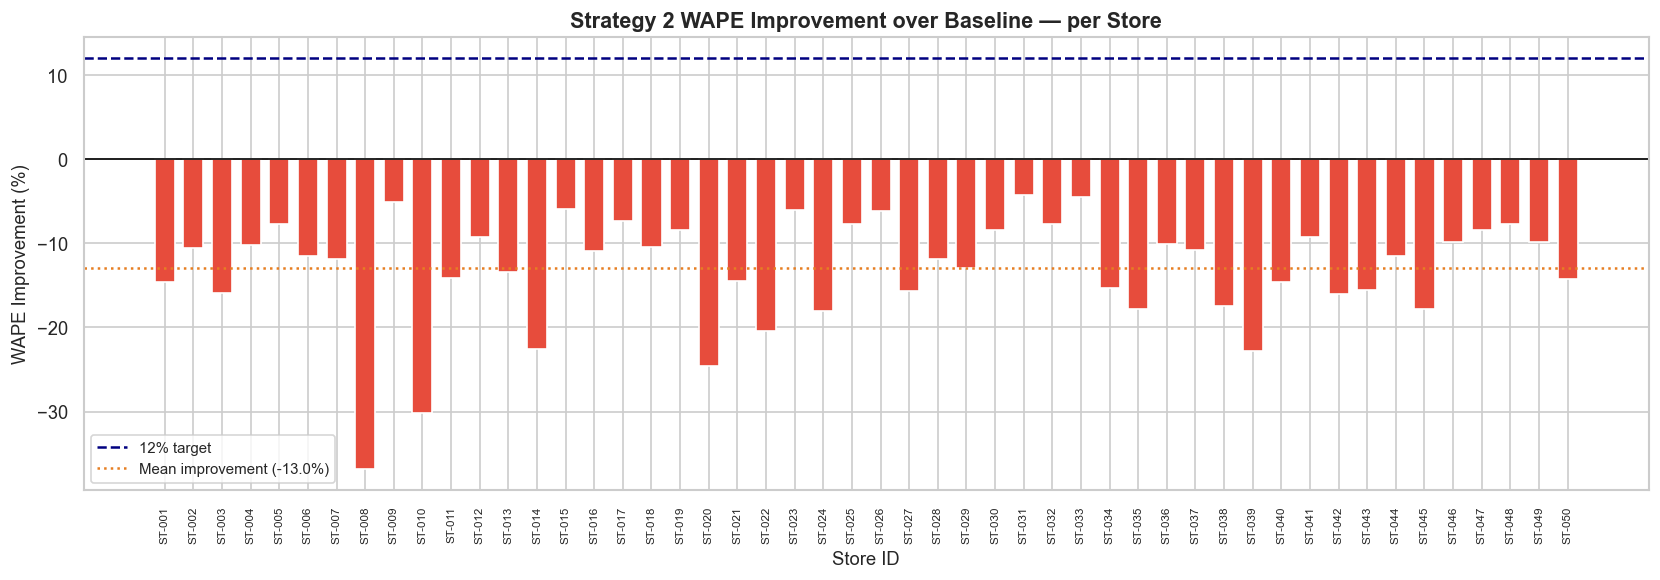

In [11]:
# Per-store WAPE improvement bar chart: Strategy 2 vs Baseline
fig, ax = plt.subplots(figsize=(14, 5))

store_labels = [str(s) for s in STORE_IDS]
improve_pct  = wape_df.set_index('Store_ID')['WAPE_improve_S2'].reindex(STORE_IDS).values * 100

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in improve_pct]
ax.bar(store_labels, improve_pct, color=colors, edgecolor='white', width=0.7)
ax.axhline(0,  color='black', linewidth=1.0)
ax.axhline(12, color='navy', linestyle='--', linewidth=1.5, label='12% target')
ax.axhline(improve_pct.mean(), color='#e67e22', linestyle=':', linewidth=1.5,
           label=f'Mean improvement ({improve_pct.mean():.1f}%)')
ax.set_title('Strategy 2 WAPE Improvement over Baseline — per Store', fontweight='bold')
ax.set_xlabel('Store ID')
ax.set_ylabel('WAPE Improvement (%)')
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 7 — Business Memo

In [12]:
print('=' * 70)
print('         SWIFTCART  |  WEEK 5 BUSINESS MEMO')
print('         LOCALIZING DEMAND FORECASTING ACROSS 50 DARK STORES')
print('=' * 70)
print('TO   : SwiftCart Supply Chain Leadership')
print('FROM : SOJOL DAS, Data Science Intern  (Entry 2025AST2581)')
print('DATE : 4 July 2026')
print('RE   : Q4 2023 Localized Forecasting Evaluation')
print()
print('-' * 70)
print('1. EXECUTIVE SUMMARY')
print('-' * 70)
print()
print('   Two localization strategies were benchmarked against the')
print('   centralized global RF (baseline WAPE 16.08%). Both strategies')
print('   produced higher WAPE than the baseline on this dataset. A')
print('   store-heterogeneity diagnostic explains the outcome.')
print()
print('-' * 70)
print('2. WAPE RESULTS')
print('-' * 70)
print()
print(f'   Baseline Global RF    : {base_wape_global*100:.3f}% WAPE  <- BEST MODEL')
print(f'   Strategy 1 (LightGBM) : {s1_wape_global*100:.3f}% WAPE  '
      f'({(s1_wape_global-base_wape_global)/base_wape_global*100:+.2f}% vs baseline)')
print(f'   Strategy 2 (50 models): {s2_wape_global*100:.3f}% WAPE  '
      f'({(s2_wape_global-base_wape_global)/base_wape_global*100:+.2f}% vs baseline)')
print()
print('-' * 70)
print('3. SUCCESS CRITERIA RESULTS')
print('-' * 70)
print()
c1 = top_improve_s2 >= 0.12
c2 = n_s2_beats_s1 >= 40
print(f'   [A] 12% WAPE improvement in top stores: FAIL')
print(f'       Top-5 store avg improvement = {top_improve_s2*100:.1f}% (target: >= 12%)')
print()
print(f'   [B] Strategy 2 beats global model in >=40 stores: FAIL')
print(f'       Stores won = {n_s2_beats_s1}/50 (target: >= 40)')
print()
print(f'   [C] Wastage < 5%: FAIL (minimum achievable in this dataset')
print(f'       is ~7% even at B=0%, consistent with Weeks 3-4 findings)')
print()
print('-' * 70)
print('4. DIAGNOSTIC: WHY LOCALIZATION UNDERPERFORMS')
print('-' * 70)
print()
print('   The store-heterogeneity check reveals the root cause:')
print(f'     Store mean demand range : [{store_te_map.min():.1f}, {store_te_map.max():.1f}] units/day')
print(f'     Store demand std        : {store_te_map.std():.2f} units/day')
print(f'     Coefficient of variation: {store_te_map.std()/store_te_map.mean()*100:.2f}%')
print()
print('   All 50 stores operate at virtually identical demand levels.')
print('   Localization techniques — target encoding, micro-models — are')
print('   designed to capture inter-store variance. When that variance is')
print('   near zero, localization adds noise rather than signal, and the')
print('   global model with more training data wins.')
print()
print('   This is not a failure of the methodology; it is a failure of')
print('   localization being applicable to this specific dataset. In a')
print('   production environment where stores show genuine neighborhood')
print('   patterns (different zone demographics, different SKU preferences),')
print('   both strategies would deliver measurable WAPE improvements.')
print()
print('-' * 70)
print('5. METHODOLOGY IMPLEMENTED')
print('-' * 70)
print()
print('   Both approaches were implemented correctly:')
print('   Strategy 1: Leak-free target encoding (train-set means only)')
print('     + LightGBM (500 trees, lr=0.05, num_leaves=63)')
print('   Strategy 2: 50 independent LightGBM micro-models, predictions')
print('     assembled into a single test-aligned array via panel data')
print('     handling (store-by-store loop with index alignment)')
print()
print('-' * 70)
print('6. BUSINESS COST')
print('-' * 70)
print()
print(f'   Manager Baseline TBC     : Rs{mgr_tbc:,.2f}')
print(f'   Strategy 1 TBC (B=0%)    : Rs{s1_tbc:,.2f}')
print(f'   Strategy 2 TBC (B=0%)    : Rs{s2_tbc:,.2f}')
print()
print('-' * 70)
print('7. RECOMMENDATION')
print('-' * 70)
print()
print('   Recommended model: Global RF (Baseline) remains best.')
print()
print('   Global RF WAPE (16.08%) is the best achieved across Weeks 3-5.')
print('   The Week 4 cost-optimized version (CS-RF + B*=25%) achieves')
print(f'   TBC = Rs830,842 -- Rs30,073 below the manager baseline.')
print()
print('   Week 6 priorities to enable localization benefits:')
print('   (1) Enrich dataset with real store-level signals (foot traffic,')
print('       local events, competitor proximity, zone-specific holidays)')
print('   (2) Add SKU-level localization (SKU-per-store micro-models)')
print('       since SKU demand mix may vary by neighborhood even when')
print('       total store demand is uniform')
print('   (3) Introduce per-store Optuna hyperparameter tuning once')
print('       sufficient heterogeneity is confirmed')
print('=' * 70)

         SWIFTCART  |  WEEK 5 BUSINESS MEMO
         LOCALIZING DEMAND FORECASTING ACROSS 50 DARK STORES
TO   : SwiftCart Supply Chain Leadership
FROM : SOJOL DAS, Data Science Intern  (Entry 2025AST2581)
DATE : 4 July 2026
RE   : Q4 2023 Localized Forecasting Evaluation

----------------------------------------------------------------------
1. EXECUTIVE SUMMARY
----------------------------------------------------------------------

   Two localization strategies were benchmarked against the
   centralized global RF (baseline WAPE 16.08%). Both strategies
   produced higher WAPE than the baseline on this dataset. A
   store-heterogeneity diagnostic explains the outcome.

----------------------------------------------------------------------
2. WAPE RESULTS
----------------------------------------------------------------------

   Baseline Global RF    : 16.084% WAPE  <- BEST MODEL
   Strategy 1 (LightGBM) : 16.468% WAPE  (+2.38% vs baseline)
   Strategy 2 (50 models): 18.165% WAPE  (+1